# Counterfeit Medication Dataset Notebook

This notebook summarizes the provided Roboflow dataset, shows the train/valid/test and label distributions, defines a transfer-learning classifier, and includes a ready-to-run evaluation block for the first performance report.

The dataset is multi-label: some samples can be marked as both `authentic` and `counterfeit`.

In [21]:
%pip install -q matplotlib numpy pandas seaborn pillow tensorflow scikit-learn



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

In [23]:

DATA_ROOT = Path("/Users/mac/Desktop/capstone-prep/Counterfeit_med_detection.v1i.multiclass")
CLASS_NAMES = ["authentic", "counterfeit"]
SPLITS = ["train", "valid", "test"]

In [24]:
def load_split(split: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_ROOT / split / "_classes.csv")
    df = df.copy()
    df["split"] = split
    df["label_count"] = df[CLASS_NAMES].sum(axis=1)
    df["primary_label"] = df[CLASS_NAMES].idxmax(axis=1)
    df["image_path"] = df["filename"].apply(lambda name: DATA_ROOT / split / name)
    return df

df = pd.concat([load_split(split) for split in SPLITS], ignore_index=True)

split_summary = df.groupby("split").agg(
    samples=("filename", "count"),
    authentic_positives=("authentic", "sum"),
    counterfeit_positives=("counterfeit", "sum"),
    both_labels=("label_count", lambda s: int((s == 2).sum())),
)

split_summary

,samples,authentic_positives,counterfeit_positives,both_labels
split,,,,
test,11,6,6,1
train,203,85,165,47
valid,19,6,16,3


/var/folders/rn/1v41__mj3js2vz19dx6fb76c0000gn/T/ipykernel_5697/1302156696.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_totals.index, y=class_totals.values, ax=axes[0, 1], palette="crest")
/var/folders/rn/1v41__mj3js2vz19dx6fb76c0000gn/T/ipykernel_5697/1302156696.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label_count", data=df, ax=axes[1, 0], palette="magma")


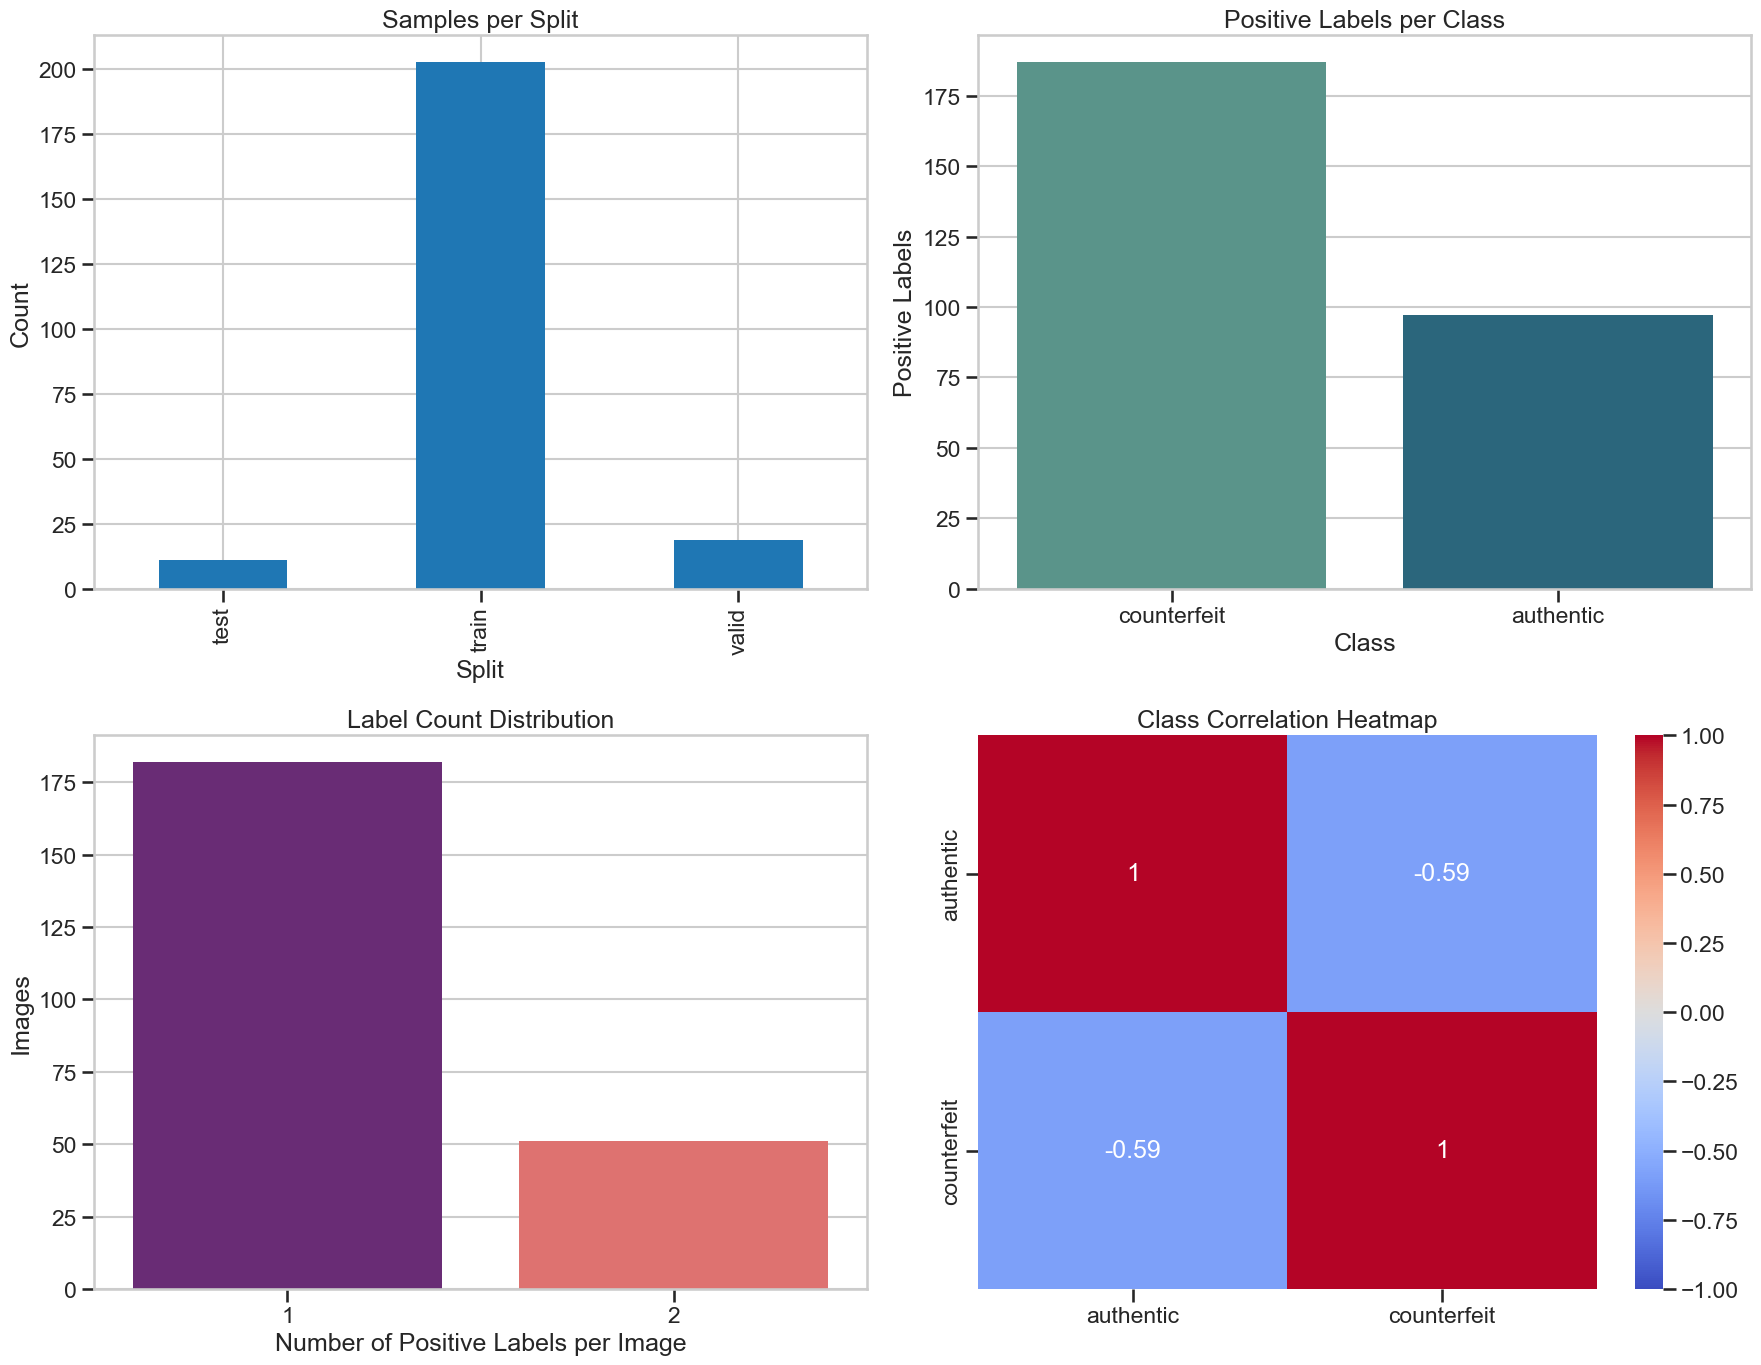

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

split_summary["samples"].plot(kind="bar", ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Samples per Split")
axes[0, 0].set_xlabel("Split")
axes[0, 0].set_ylabel("Count")

class_totals = df[CLASS_NAMES].sum().sort_values(ascending=False)
sns.barplot(x=class_totals.index, y=class_totals.values, ax=axes[0, 1], palette="crest")
axes[0, 1].set_title("Positive Labels per Class")
axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("Positive Labels")

sns.countplot(x="label_count", data=df, ax=axes[1, 0], palette="magma")
axes[1, 0].set_title("Label Count Distribution")
axes[1, 0].set_xlabel("Number of Positive Labels per Image")
axes[1, 0].set_ylabel("Images")

co_occurrence = df[CLASS_NAMES].corr()
sns.heatmap(co_occurrence, annot=True, vmin=-1, vmax=1, cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Class Correlation Heatmap")

plt.tight_layout()

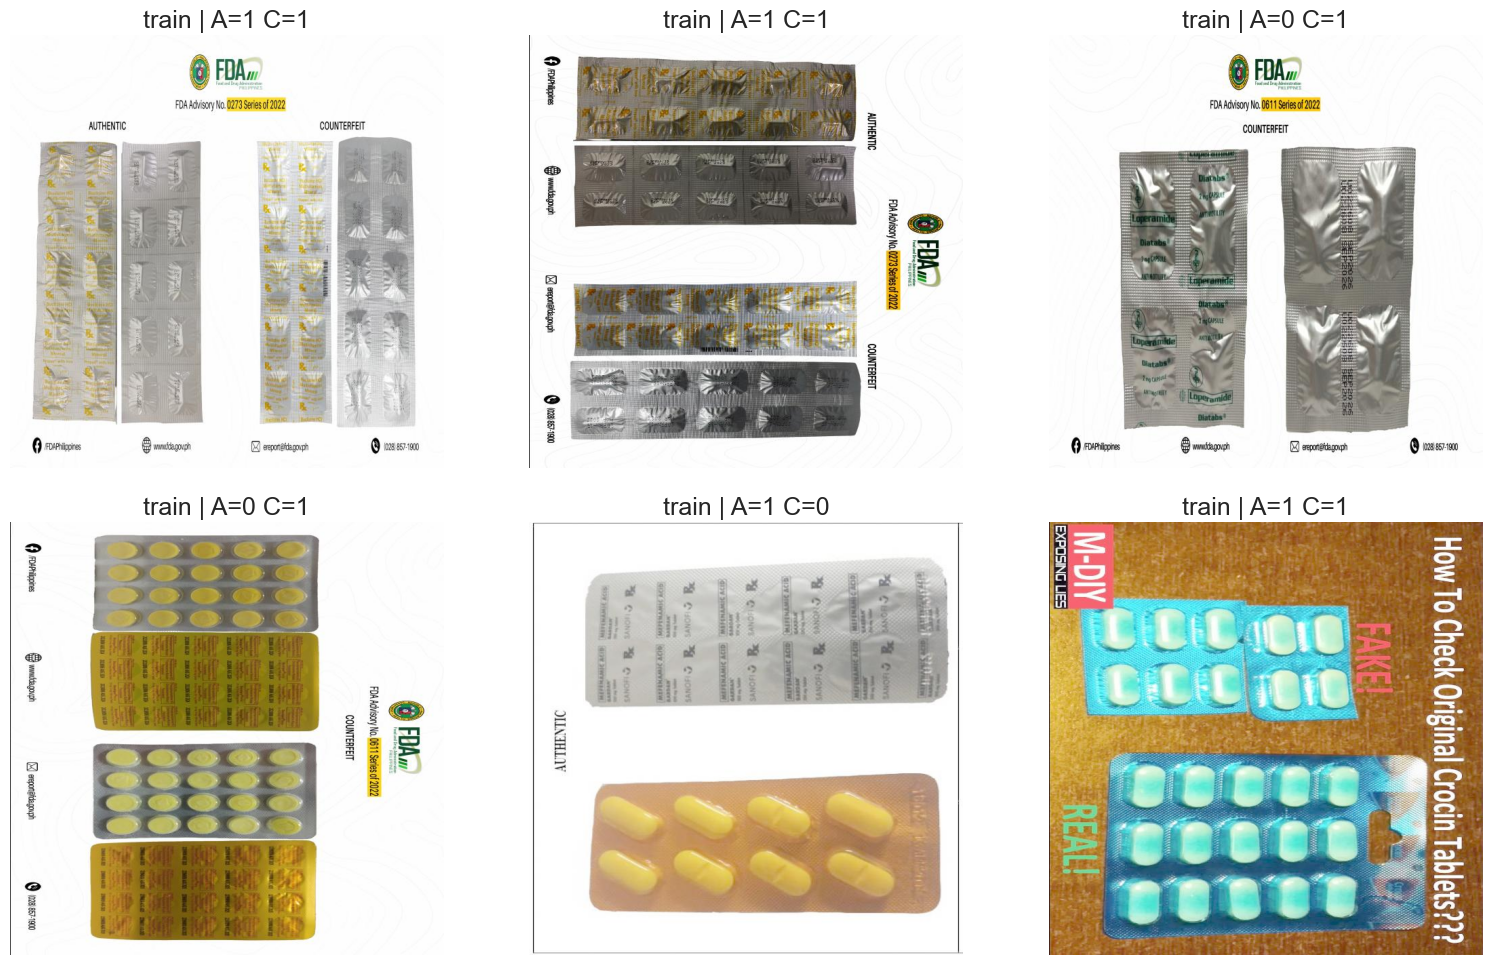

In [26]:
sample_df = df.sample(min(6, len(df)), random_state=7).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    image = Image.open(row["image_path"])
    ax.imshow(image)
    ax.set_title(f"{row['split']} | A={int(row['authentic'])} C={int(row['counterfeit'])}")
    ax.axis("off")

for ax in axes.ravel()[len(sample_df):]:
    ax.axis("off")

plt.tight_layout()

In [27]:


def make_dataset(split: str, shuffle: bool = False) -> tf.data.Dataset:
    split_df = load_split(split)
    file_paths = split_df["image_path"].astype(str).tolist()
    labels = split_df[CLASS_NAMES].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(split_df), seed=42, reshuffle_each_iteration=True)

    def _load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32)
        return image, label

    ds = ds.map(_load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset("train", shuffle=True)
valid_ds = make_dataset("valid")
test_ds = make_dataset("test")

## Model Architecture

The model below uses transfer learning with `EfficientNetB0` as the frozen feature extractor. It keeps the output layer sigmoid-based because the dataset is multi-label, and it compiles with Adam and binary cross-entropy.

Architecture summary:
- Input resizing to 224 x 224
- Rescaling and lightweight augmentation
- EfficientNetB0 backbone, initialized with ImageNet weights and frozen at first
- Global average pooling
- Dense layer with ReLU activation
- Dropout regularization
- Sigmoid output for the two labels
- Adam optimization with a small learning rate for stable fine-tuning

In [28]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
    ],
    name="augmentation",
)

inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = layers.Rescaling(1.0 / 255.0)(inputs)
x = data_augmentation(x)

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(*IMG_SIZE, 3),
)
base_model.trainable = False
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="sigmoid", name="labels")(x)

model = keras.Model(inputs, outputs, name="counterfeit_detector")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

model.summary()


Model: "counterfeit_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ labels (Dense)                  │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,021 (16.70 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Initial Training

Run a short baseline training pass to establish initial model behavior before full tuning.


In [29]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    verbose=1,
)

print("\nTraining complete. Summary:")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 871ms/step - accuracy: 0.6453 - auc: 0.5000 - loss: 0.6928 - precision: 0.8081 - recall: 0.5560 - val_accuracy: 0.7632 - val_auc: 0.5000 - val_loss: 0.6922 - val_precision: 0.8421 - val_recall: 0.7273
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 715ms/step - accuracy: 0.6970 - auc: 0.5028 - loss: 0.6920 - precision: 0.8128 - recall: 0.6600 - val_accuracy: 0.7632 - val_auc: 0.7699 - val_loss: 0.6912 - val_precision: 0.8421 - val_recall: 0.7273
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 716ms/step - accuracy: 0.6970 - auc: 0.6894 - loss: 0.6911 - precision: 0.8128 - recall: 0.6600 - val_accuracy: 0.7632 - val_auc: 0.7699 - val_loss: 0.6902 - val_precision: 0.8421 - val_recall: 0.7273
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 782ms/step - accuracy: 0.6970 - auc: 0.7082 - loss: 0.6903 - precision: 0.8128 - recall: 0.6600 - val_accuracy: 0.7632 - val_auc: 0.7699 - val_loss: 0.6891 - val_precision: 0.8421 - val_recall: 0.7273
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 781ms

## Initial Performance Metrics

Evaluate the trained model on the test split and report subset accuracy, micro-precision, micro-recall, and micro-F1.


In [30]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

y_prob = model.predict(test_ds)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    "subset_accuracy": accuracy_score(y_true, y_pred),
    "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
    "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
    "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
}

pd.Series(metrics, name="initial_metrics")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

   authentic       0.00      0.00      0.00         6
 counterfeit       0.55      1.00      0.71         6

   micro avg       0.55      0.50      0.52        12
   macro avg       0.27      0.50      0.35        12
weighted avg       0.27      0.50      0.35        12
 samples avg       0.55      0.50      0.52        12



## Export Trained Model

Save the trained model so the API can load it for inference.


In [31]:
from pathlib import Path

ARTIFACT_DIR = Path("/Users/mac/Desktop/capstone-prep/artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "counterfeit_detector.keras"

model.save(MODEL_PATH)
print(f"Saved model to: {MODEL_PATH}")


Saved model to: /Users/mac/Desktop/capstone-prep/artifacts/counterfeit_detector.keras
